# monogpt API KEY langchain 사용

# API Key 로딩

In [ ]:
# .env
# LLM_API_KEY=your_api_key

In [ ]:
# uv add langchain python-dotenv jupyterlab ipykernel

In [3]:
import os
from dotenv import load_dotenv
from langchain_openai import ChatOpenAI

load_dotenv(override=True)

api_key = os.getenv("LLM_API_KEY")

BASE_URL = "https://monogpt.kr/api/monorouter/v1"

## OpenAI 모델

In [60]:
llm = ChatOpenAI(
    model="gpt-5.5",
    api_key=api_key,
    base_url=BASE_URL,
    use_responses_api=False,  # base url로 할 때는 이부분 넣어야 함.
    max_tokens=526
)

In [61]:
response = llm.invoke("파이썬 계산기 코드 작성해줘")

print(response.content)

아래는 간단한 **파이썬 콘솔 계산기 코드**입니다.

```python
def add(a, b):
    return a + b

def subtract(a, b):
    return a - b

def multiply(a, b):
    return a * b

def divide(a, b):
    if b == 0:
        return "0으로 나눌 수 없습니다."
    return a / b


while True:
    print("\n=== 파이썬 계산기 ===")
    print("1. 더하기")
    print("2. 빼기")
    print("3. 곱하기")
    print("4. 나누기")
    print("5. 종료")

    choice = input("원하는 연산을 선택하세요: ")

    if choice == "5":
        print("계산기를 종료합니다.")
        break

    if choice not in ["1", "2", "3", "4"]:
        print("잘못된 선택입니다.")
        continue

    try:
        num1 = float(input("첫 번째 숫자 입력: "))
        num2 = float(input("두 번째 숫자 입력: "))
    except ValueError:
        print("숫자만 입력해주세요.")
        continue

    if choice == "1":
        result = add(num1, num2)
    elif choice == "2":
        result = subtract(num1, num2)
    elif choice == "3":
        result = multiply(num1, num2)
    elif choice == "4":
        result = divide(num1, num2)

    print("결과:", result

In [12]:
from IPython.display import display, Markdown

display(Markdown(response.content))

# Agentic RAG 초보자 가이드

## 1️⃣ RAG가 뭔가요?

먼저 **RAG(Retrieval-Augmented Generation)**를 이해해야 합니다.

```
일반 AI: 학습된 데이터만 사용 → 최신 정보 없음, 환각(hallucination) 발생

RAG: AI + 검색 엔진 = 문서에서 정보 찾아서 답변
```

**예시**
- ❌ 일반 AI: "2024년 대통령은?" → 학습 데이터에만 의존
- ✅ RAG: 최신 뉴스 DB 검색 → 정확한 답변

---

## 2️⃣ 그럼 Agentic RAG는?

**RAG에 "자율성"을 추가한 것**입니다.

### 일반 RAG의 한계
```
질문 → 문서 검색 → 답변
(한 번만 검색, 같은 방식으로만 검색)
```

### Agentic RAG
```
질문 → AI가 생각 → 여러 도구 활용 → 자동 재검색 → 최종 답변
(검색 전략을 자체 판단!)
```

---

## 3️⃣ 구체적인 비교

| 항목 | 일반 RAG | Agentic RAG |
|------|---------|-----------|
| **검색 방식** | 정해진 방식 | AI가 판단해서 선택 |
| **재검색** | 안 함 | 필요시 자동 재검색 |
| **복잡한 질문** | 약함 | 강함 |
| **사용 도구** | DB만 | DB, 계산기,

## Claude 모델

In [7]:
# claude = ChatOpenAI(
#     model="claude-haiku-4.5",
#     api_key=api_key,
#     base_url=BASE_URL,
#     temperature=0,
#     max_tokens=512,
# )

claude = ChatOpenAI(
    model="claude-haiku-4.5",
    api_key=api_key,
    base_url=BASE_URL,
    use_responses_api=False,  # base url로 할 때는 이부분 넣어야 함.(MonoRouter 사용)
    max_tokens=526
)

```text
LangChain
   ↓
ChatOpenAI
   ↓
use_responses_api=False
   ↓
POST /chat/completions
   ↓
MonoRouter
   ↓
Gemini
```

In [8]:
response = claude.invoke(
    "LangGraph와 LangChain의 차이를 설명해줘"
)

print(response.content)

# LangGraph vs LangChain 비교

## 핵심 차이점

| 구분 | LangChain | LangGraph |
|------|----------|----------|
| **목적** | LLM 애플리케이션 개발 라이브러리 | 상태 기반 멀티 에이전트 워크플로우 |
| **구조** | 선형/순차 처리 중심 | 그래프 기반 상태 머신 |
| **제어** | 자동 처리 (자유도 낮음) | 명시적 제어 (자유도 높음) |
| **관계** | 독립 라이브러리 | LangChain 위에 구축됨 |

---

## 자세한 설명

### 1. **LangChain**
```python
from langchain.chains import LLMChain
from langchain.prompts import PromptTemplate

# 선형적인 체인 구성
chain = prompt | llm | output_parser

# 한 번에 실행
result = chain.invoke({"input": "query"})
```

**특징:**
- LLM, 프롬프트, 메모리, 도구 등을 **조합**하는 라이브러리
- 비교적 **단순한 선형 플로우**에 적합
- RAG, 간단한 에이전트 등에 활용

---

### 2. **LangGraph**
```python
from langgraph.graph import StateGraph, END

# 상태 정의
class State(TypedDict):
    input: str
    output: str
    steps: list

# 그래프 구성
graph = StateGraph(State)

graph.add_node("node1", function1)
graph.add_node("node2", function2)
graph.add_edge("node1", "node2")
graph.add_conditional_edges("node2", condition_func)

# 조건


In [10]:
response

AIMessage(content='# Agentic RAG 초보자 가이드\n\n## 1️⃣ 기본 개념부터 시작하기\n\n### RAG란?\n**RAG = Retrieval-Augmented Generation (검색 강화 생성)**\n\n```\n일반 AI: "안녕하세요" → AI가 학습 데이터로만 답변\nRAG: "우리 회사 정책은?" → 문서 검색 + AI 답변\n```\n\n💡 **핵심**: 최신 정보나 회사 문서를 AI에게 "보여주고" 답변하게 하는 것\n\n---\n\n## 2️⃣ Agentic RAG = RAG + 에이전트 능력\n\n### 일반 RAG의 한계\n```\n사용자: "지난 분기 매출과 현재 프로젝트 진행도를 비교해줘"\n\n❌ 문제: \n- 문서 1개만 검색\n- 여러 질문을 나누어서 물어봐야 함\n- 스스로 판단할 수 없음\n```\n\n### Agentic RAG의 해결책\n```\n사용자: "지난 분기 매출과 현재 프로젝트 진행도를 비교해줘"\n\n✅ AI가 스스로:\n1. "분기별 매출 문서를 찾아야겠다" → 검색\n2. "프로젝트 진행도 문서도 필요하다" → 검색\n3. 두 정보를 비교 분석 → 답변\n\n🤖 에이전트처럼 **생각하고 실행**하는 것!\n```\n\n---\n\n## 3️⃣ 구체적인 작동 원리\n\n### 단계별 프로세스\n\n```\n┌─────────────────────────────────────────┐', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 526, 'prompt_tokens': 46, 'total_tokens': 572, 'completion_tokens_details': None, 'prompt_tokens_details': None}, 'model_provider': 'openai', 'model_name': 'claude-haiku-4.5', 'system_fing

In [13]:
from langchain_core.messages import (
    SystemMessage,
    HumanMessage
)

messages = [
    SystemMessage(
        content="당신은 생성형 AI 전문 강사입니다."
    ),
    HumanMessage(
        content="Agentic RAG를 초보자에게 설명해줘."
    )
]

response = claude.invoke(messages)

display(Markdown(response.content))

# Agentic RAG 초보자 가이드

## 🎯 핵심 개념

**Agentic RAG**는 AI 에이전트가 지능적으로 정보를 검색하고 활용하는 시스템입니다.

### 기존 RAG vs Agentic RAG

```
기존 RAG:
Query → 벡터DB 검색 → 문서 추출 → LLM 답변
(정해진 절차를 따름)

Agentic RAG:
Query → 에이전트가 판단 → 여러 도구 선택적 사용 
       → 필요하면 재검색 → LLM 답변
(상황에 따라 유연하게 대응)
```

---

## 💡 쉽게 비유하면

**기존 RAG**: 도서관원이 한 번 책을 가져다주는 것
- 처음 검색 결과로 답변함

**Agentic RAG**: 똑똑한 도서관원
- "이 정보가 부족한가?" 판단
- "다른 섹션도 봐야 하나?" 생각
- 필요하면 추가 검색
- 여러 출처를 종합해서 답변

---

## 🛠️ 주요 구성 요소

```python
Agentic RAG = 3가지 기능

1️⃣ 에이전트 (Agent)
   └─ "뭘 해야 할까?" 판단하는 두뇌

2️⃣ 도구 (Tools)
   ├─ 벡터DB 검색
   ├─ 계산기
   ├─ 웹 검색
   └─ API 호출 등

3️⃣ 메모리 (Memory)
   └─ 대화

## Gemini 모델

In [5]:
gemini = ChatOpenAI(
    model="gemini-3.5-flash",
    api_key=api_key,
    base_url=BASE_URL,
    temperature=0,
    use_responses_api=False,  # base url로 할 때는 이부분 넣어야 함.(MonoRouter 사용)
    max_tokens=2048,
    # max_tokens=512,
    reasoning_effort="minimal"
)


# GPT / Claude / Gemini를 하나의 함수로 처리

In [14]:
from langchain_openai import ChatOpenAI


def get_llm(
    model: str,
    temperature: float = 0,
    max_tokens: int = 512
):
    return ChatOpenAI(
        model=model,
        api_key=api_key,
        base_url=BASE_URL,
        temperature=temperature,
        use_responses_api=False,  # base url로 할 때는 이부분 넣어야 함.(MonoRouter 사용)
        max_tokens=max_tokens,
    )

In [15]:
response = gemini.invoke("RAG를 설명해줘")

print(response)
# print(response.content)

content='**RAG(Retrieval-Augmented Generation, 검색 증강 생성)**는 거대 언어 모델(LLM)의 한계를 극복하기 위해 최근 AI 분야에서 가장 주목받고 있는 기술입니다.\n\n쉽게 한 줄로 요약하자면, **"AI에게 오픈북 시험을 보게 하는 기술"**입니다.\n\n이해하기 쉽게 개념, 필요성, 작동 원리, 장점을 나누어 설명해 드릴게요.\n\n---\n\n### 1. 왜 RAG가 필요할까요? (기존 LLM의 한계)\n\nChatGPT 같은 기존의 LLM은 학습된 데이터만을 바탕으로 답변을 생성합니다. 이로 인해 다음과 같은 치명적인 단점이 있습니다.\n\n1. **환각 현상(Hallucination):** 모르는 내용도 마치 사실인 것처럼 그럴듯하게 거짓말을 합니다.\n2. **정보의 최신성 부족:** 학습이 끝난 시점 이후의 최신 정보는 알지 못합니다. (예: "어제 주식 시장 어땠어?"에 답하지 못함)\n3. **내부 데이터 접근 불가:** 기업의 대외비 문서나 개인의 사적인 파일은 학습되지 않았기 때문에 답변할 수 없습니다.\n\n---\n\n### 2. RAG의 핵심 비유: "오픈북 시험"\n\n* **기존 LLM (암기 시험):** 머릿속에 기억된 지식만으로 답을 씁니다. 기억이 안 나면 소설을 씁니다.\n* **RAG 적용 LLM (오픈북 시험):** 문제를 받으면, 먼저 **관련 서적(외부 데이터베이스)에서 정답에 가까운 내용을 찾아본 뒤(Retrieval)**, 그 내용을 참고하여 **정확한 답변을 작성(Generation)**합니다.\n\n---\n\n### 3. RAG는 어떻게 작동하나요? (3단계 과정)\n\n사용자가 질문을 던졌을 때 RAG 시스템은 내부적으로 다음과 같이 움직입니다.\n\n1. **검색 (Retrieval):**\n   * 사용자의 질문(예: "우리 회사 올해 복지 정책이 어떻게 돼?")이 들어오면, AI는 준비된 외부 데이터베이스(문서, 웹페이지, 사내 Wiki 등)에서 질문과 가장

## claude 모델

In [67]:
llm = get_llm("claude-haiku-4.5")

response = llm.invoke(
    "RAG란 무엇인가?"
)

print(response.content)

# RAG(Retrieval-Augmented Generation)란?

RAG는 **검색 기반 생성형 AI 기술**입니다. 대규모 언어모델(LLM)이 외부 데이터베이스에서 관련 정보를 먼저 검색한 후, 그 정보를 바탕으로 답변을 생성하는 방식입니다.

## 작동 원리

```
사용자 질문 → 관련 정보 검색 → 검색 결과 + 질문 → LLM → 답변 생성
```

## 주요 특징

| 구분 | 설명 |
|------|------|
| **장점** | • 최신 정보 활용 가능<br>• 할루시네이션(거짓 정보) 감소<br>• 특정 도메인 지식 활용 |
| **단점** | • 검색 품질에 의존<br>• 처리 속도 증가<br>• 시스템 복잡도 상승 |

## 활용 사례

- 📚 **기업 문서 기반 Q&A** - 사내 매뉴얼, 정책 검색
- 🏥 **의료 정보 제공** - 최신 의료 데이터 활용
- 📰 **뉴스 요약** - 최신 뉴스 기반 답변
- 🛒 **고객 지원** - 제품 정보 기반 상담

## 일반 LLM과의 차이

**일반 LLM**: 학습된 데이터만 사용 → 오래된 정보, 오류 가능성

**RAG**: 실시간 검색 + 생성 → 최신


## GPT 모델

In [68]:
llm = get_llm("gpt-5.4")
response = llm.invoke(
    "RAG란 무엇인가?"
)

print(response.content)

RAG는 보통 **Retrieval-Augmented Generation**의 약자입니다.  
한국어로는 **검색 증강 생성** 정도로 볼 수 있습니다.

간단히 말하면:

- **LLM(대형 언어 모델)** 이
- 자기 내부 지식만으로 답하는 대신,
- 먼저 **외부 문서/DB/검색 시스템에서 관련 정보를 찾아오고(Retrieval)**,
- 그 정보를 바탕으로 **답변을 생성하는(Generation)** 방식입니다.

## 왜 쓰나?
일반 LLM은:
- 최신 정보에 약할 수 있고
- 특정 회사 내부 문서 같은 비공개 정보는 모를 수 있으며
- 때때로 사실이 아닌 내용을 그럴듯하게 말하는 **환각(hallucination)** 문제가 있습니다.

RAG를 쓰면:
- 최신 문서 반영 가능
- 사내 문서 기반 답변 가능
- 답변 근거 제시 가능
- 환각을 줄이는 데 도움

## 동작 흐름
보통 이렇게 작동합니다:

1. 사용자가 질문
2. 시스템이 질문과 관련된 문서 조각들을 검색
3. 검색된 문서를 프롬프트에 함께 넣음
4. LLM이 그 문서를 참고해 답변 생성

## 예시
질문:  
“우리 회사 환불 정책이 어떻게 되나요?”

RAG 방식:
- 회사 정책 문서에서 “환불 규정” 부분을 검색
- 해당 내용을 LLM에 전달
- LLM이 그 문서를 바탕으로 자연스럽게 답변

즉, **모델이 기억에 의존하지 않고, 필요한 정보를 찾아서 답하는 구조**입니다.

## 어디에 많이 쓰나?
- 사내 챗봇
- 고객지원 챗봇
- 법률/의료 문서 검색 보조
- 논문/매뉴얼 Q&A
- 개인 지식베이스 검색

원하시면 다음으로  
**“RAG의 구조(벡터DB, 임베딩, 리랭킹 포함)”**까지 이어서 설명해드릴게요.


## Gemini 모델

In [70]:
gemini = get_llm("gemini-3.8-flash")
response = gemini.invoke(
    "RAG란 무엇인가?"
)

print(response.content)

)**의 약자입니다. LLM이 답변을 생성할 때, 외부 지


# PromptTemplate과 Claude 연결

In [20]:
from langchain_core.prompts import ChatPromptTemplate

prompt = ChatPromptTemplate.from_messages([
    (
        "system",
        "당신은 AI 교육 전문 강사입니다."
    ),
    (
        "human",
        "{question}"
    )
])

claude = get_llm("claude-haiku-4.5")

chain = prompt | claude

In [21]:
response = chain.invoke({
    "question": "Naive RAG와 Agentic RAG의 차이를 설명해줘."
})

display(Markdown(response.content))

# Naive RAG vs Agentic RAG 비교

## 1. **Naive RAG (기본 RAG)**

### 구조
```
사용자 질문 → 검색 → 문서 검색 → LLM 응답
```

### 특징
- **단순한 선형 흐름**: 질문 → 검색 → 생성
- **고정된 프로세스**: 항상 같은 방식으로 동작
- **한 번의 검색**: 초기 쿼리로 문서를 한 번만 검색

### 장점
✅ 구현이 간단하고 빠름
✅ 예측 가능한 동작
✅ 비용이 저렴함

### 단점
❌ 복잡한 질문에 약함
❌ 검색 결과가 부족하면 답변 품질 저하
❌ 추가 정보 필요 시 대응 불가

---

## 2. **Agentic RAG (에이전트 기반 RAG)**

### 구조
```
사용자 질문 → 에이전트 판단 → 검색/도구 활용 → 재검색 → LLM 응답
```

### 특징
- **동적 의사결정**: 상황에 따라 다른 행동 선택
- **반복적 검색**: 필요시 여러 번 검색 가능
- **도구 활용**: 검색 외 다양한 도구 사용 가능
- **자율적 계획**: 문제 해결을 위한 전략 수립

### 장점
✅ 복잡한 질문 처리 가능
✅ 부족한 정보 자동 보충
✅ 다양한 도

# LangGraph에서 사용

In [22]:
from langgraph.graph import (
    StateGraph,
    MessagesState,
    START,
    END
)

claude = get_llm("claude-haiku-4.5")

In [23]:
def chatbot(state: MessagesState):

    response = claude.invoke(
        state["messages"]
    )

    return {
        "messages": [response]
    }

In [24]:
builder = StateGraph(MessagesState)

builder.add_node(
    "chatbot",
    chatbot
)

builder.add_edge(
    START,
    "chatbot"
)

builder.add_edge(
    "chatbot",
    END
)

graph = builder.compile()

## Graph 시각화

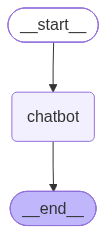

In [33]:
from IPython.display import Image, display

display(
    Image(
        graph.get_graph().draw_mermaid_png()
    )
)

## graph 실행

In [25]:
result = graph.invoke({
    "messages": [
        {
            "role": "user",
            "content": "Modular RAG를 설명해줘"
        }
    ]
})

## 결과 출력

In [34]:
display(
    Markdown(
        result["messages"][-1].content
    )
)

# Modular RAG (검색 증강 생성) 설명

## 📌 기본 개념

**Modular RAG**는 RAG 시스템을 독립적인 모듈로 분리하여 각 모듈을 유연하게 조합하고 최적화할 수 있는 아키텍처입니다.

---

## 🏗️ 핵심 모듈 구성

```
┌─────────────────────────────────────────┐
│         사용자 쿼리 입력                  │
└────────────┬────────────────────────────┘
             │
    ┌────────▼────────┐
    │  쿼리 처리 모듈  │ (Query Processing)
    └────────┬────────┘
             │
    ┌────────▼────────┐
    │  검색 모듈       │ (Retrieval)
    └────────┬────────┘
             │
    ┌────────▼────────┐
    │  재순위 모듈     │ (Reranking)
    └────────┬────────┘
             │
    ┌────────▼────────┐
    │  생성 모듈       │ (Generation)
    └────────┬────────┘
             │
    ┌────────▼────────┐
    │  최종 답변       │
    └─────────────────┘
```

### 주요 모듈들

| 모듈 | 역할 | 예시 |
|------|------|------|
| **Query Processing** | 쿼리 정제/확장 | 쿼리 분해, 의도 파악 |
| **Retrieval** | 관련 문서 검색 | BM25, Dense Retrieval |
| **Reranking** | 검색 결과 재

# Local LLM과 함께 사용

uv add langchain-openai langchain-ollama

In [71]:
from langchain_openai import ChatOpenAI
from langchain_ollama import ChatOllama


MONO_BASE_URL = "https://monogpt.kr/api/monorouter/v1"
OLLAMA_BASE_URL = "http://localhost:11434"


def get_llm(
    model: str,
    provider: str = "mono",
    temperature: float = 0,
    max_tokens: int = 512
):
    
    # ── MonoGPT / OpenAI-compatible API ──
    if provider == "mono":
        return ChatOpenAI(
            model=model,
            api_key=api_key,
            base_url=MONO_BASE_URL,
            temperature=temperature,
            use_responses_api=False,
            max_tokens=max_tokens,
        )

    # ── Ollama Local LLM ──
    elif provider == "ollama":
        return ChatOllama(
            model=model,
            base_url=OLLAMA_BASE_URL,
            temperature=temperature,
            num_predict=max_tokens,
        )

    else:
        raise ValueError(
            f"지원하지 않는 provider입니다: {provider}"
        )

## MonoGPT Claude 사용

In [72]:
llm = get_llm(
    model="claude-haiku-4.5",
    provider="mono"
)

response = llm.invoke(
    "Agentic RAG를 간단하게 설명해줘."
)

print(response.content)

# Agentic RAG 간단 설명

## 기본 개념
**Agentic RAG**는 AI 에이전트가 자율적으로 정보를 검색하고 판단하는 RAG(Retrieval-Augmented Generation) 방식입니다.

## 기존 RAG vs Agentic RAG

### 기존 RAG
```
질문 → 자동 검색 → 답변 생성
(정해진 절차대로만 진행)
```

### Agentic RAG
```
질문 → 에이전트가 판단 → 검색 필요? → 검색 → 충분한가? 
→ 추가 검색 필요? → 최종 답변
(상황에 따라 유연하게 대응)
```

## 핵심 특징

| 항목 | 기존 RAG | Agentic RAG |
|------|---------|-----------|
| **검색 방식** | 자동 검색 | 필요시만 검색 |
| **판단력** | 없음 | 있음 |
| **반복 검색** | 불가능 | 가능 |
| **복잡한 질문** | 약함 | 강함 |

## 간단한 예시

**질문**: "2024년 삼성 실적과 경쟁사 비교"

- **기존 RAG**: 무조건 검색 → 답변
- **Agentic RAG**: 
  1. "삼성 실적 검색 필요" 판단
  2. 삼성 실적 검색
  3. "경쟁사 정보도 필요" 판단
  4. 경쟁사 검색
  5. 비교 분석 후 답변

더 똑똑하


## OpenAI GPT 

In [73]:
llm = get_llm(
    model="gpt-5.4",
    provider="mono"
)


response = llm.invoke(
    "Agentic RAG를 간단하게 설명해줘."
)

print(response.content)

**Agentic RAG**는  
기존 **RAG(Retrieval-Augmented Generation)**에 **에이전트적 판단/행동 능력**이 들어간 방식입니다.

### 먼저 RAG란?
RAG는 질문을 받으면:
1. 관련 문서를 **검색(Retrieval)** 하고
2. 그 결과를 바탕으로 LLM이 **답변 생성(Generation)** 하는 구조입니다.

즉, 모델이 자기 내부 지식만 쓰지 않고, 외부 문서를 찾아보고 답합니다.

---

### Agentic RAG는 뭐가 다를까?
기존 RAG는 보통  
**한 번 검색 → 한 번 답변** 흐름이 많습니다.

반면 **Agentic RAG**는 LLM이 마치 에이전트처럼:
- 무엇을 검색할지 스스로 판단하고
- 검색 결과가 부족하면 다시 검색하고
- 여러 도구(DB, 웹검색, API 등)를 선택해서 쓰고
- 중간에 계획을 수정하며
- 최종 답을 만듭니다

즉, **“찾고-검토하고-부족하면 다시 찾는” 자율적 검색형 RAG**라고 보면 됩니다.

---

### 간단한 예시
질문:  
“2024년 기준으로 한국 배터리 3사의 북미 투자 현황을 비교해줘.”

#### 일반 RAG
- 벡터DB에서 관련 문서 몇 개 검색
- 그 문서 기반으로 바로 답변 생성

#### Agentic RAG
- 우선 “배터리 3사”가 LG에너지솔루션, 삼성SDI, SK온인지 확인
- 각 회사별 최신 투자 기사/공시를 각각 검색
- 북미 투자만 필터링
- 정보가 충돌하면 추가 검색
- 부족하면 날짜 기준 최신 자료를 우선 수집
- 그 뒤 비교표 생성

---

### 왜 쓰나?
장점:
- **복잡한 질문**에 더 강함
- 정보가 부족하면 **재탐색** 가능
- 여러 출처를 조합해 **정확도 향상**
- 단계적 추론과 도구 사용이 가능

---

### 단점도 있음
- 구조가 복잡함
- 응답 시간이 더 길 수 있음
- 검색/도구 호출 비용이 늘어남
- 잘못 설계하면


## Ollama EXAONE 3.5 7.8B 사용

In [74]:
llm = get_llm(
    model="exaone3.5:7.8b",
    provider="ollama"
)

response = llm.invoke(
    "Agentic RAG를 간단하게 설명해줘."
)

print(response.content)

Agentive RAG는 **RAG 모델에 에이전트 기능을 추가한 것**입니다. 

* **RAG (Retrieval-Augmented Generation)**는 질문에 답하기 위해 **외부 지식 기반을 검색하고**, **생성 모델로 답변을 생성하는** 기술입니다. 
* **Agentive RAG**는 여기에 **목표 지향적인 행동**을 추가합니다. 즉, 단순히 정보를 제공하는 것을 넘어, **사용자의 의도를 이해하고 그에 따라 행동하는 에이전트처럼** 작동합니다.

**예시:**

* 일반 RAG는 "파리는 곤충이다"라는 질문에 답할 수 있습니다.
* Agentive RAG는 "오늘 저녁에 파리 요리를 만들어볼까?"라는 질문을 받으면, 레시피 검색, 재료 목록 제공, 조리 단계 안내 등 **다양한 행동**을 통해 사용자를 지원합니다.

핵심은 **RAG의 정보 제공 능력에 에이전트의 목표 지향적 행동을 결합**하여 더욱 **유용하고 상호 작용적인 경험**을 제공하는 것입니다.


# prefix 방식 
## langchain 사용

In [75]:
from langchain_openai import ChatOpenAI
from langchain_ollama import ChatOllama


MONO_BASE_URL = "https://monogpt.kr/api/monorouter/v1"
OLLAMA_BASE_URL = "http://localhost:11434"


def get_llm(
    model: str,
    temperature: float = 0,
    max_tokens: int = 512
):
    
    provider, model_name = model.split("/", 1)

    if provider == "mono":

        return ChatOpenAI(
            model=model_name,
            api_key=api_key,
            base_url=MONO_BASE_URL,
            temperature=temperature,
            use_responses_api=False,
            max_tokens=max_tokens,
        )

    elif provider == "ollama":

        return ChatOllama(
            model=model_name,
            base_url=OLLAMA_BASE_URL,
            temperature=temperature,
            num_predict=max_tokens,
        )

    else:
        raise ValueError(
            f"지원하지 않는 provider: {provider}"
        )

In [76]:
claude = get_llm(
    "mono/claude-haiku-4.5"
)
response = claude.invoke(
    "Naive RAG란 무엇인가?"
)

print(response.content)

# Naive RAG란?

**Naive RAG(순진한 RAG)**는 가장 기본적인 형태의 검색 증강 생성(Retrieval-Augmented Generation) 시스템입니다.

## 기본 구조

```
질문 입력 → 문서 검색 → 답변 생성
```

세 가지 단계로 이루어집니다:

1. **검색(Retrieval)**: 질문과 관련된 문서를 데이터베이스에서 찾기
2. **증강(Augmentation)**: 검색된 문서를 프롬프트에 추가
3. **생성(Generation)**: LLM이 증강된 프롬프트로 답변 생성

## 주요 특징

| 특징 | 설명 |
|------|------|
| **단순성** | 구현이 간단하고 직관적 |
| **속도** | 빠른 처리 가능 |
| **비용** | 낮은 계산 비용 |
| **한계** | 검색 품질에 크게 의존 |

## 주요 문제점

❌ **검색 오류에 취약** - 잘못된 문서 검색 시 답변 품질 저하
❌ **맥락 이해 부족** - 단순 키워드 매칭으로 의미 파악 어려움
❌ **복잡한 질문 처리 미흡** - 다단계 추론 필요한 경우 부족
❌ **순환 참조 문제** - 검색된 문서 간 연관성 미고려

## 개선 방안

더 나은 RAG 시스템을 위해:
- **Advanced RAG**: 재순위화


In [77]:
gpt = get_llm(
    "mono/gpt-5.5"
)
response = gpt.invoke(
    "Naive RAG란 무엇인가?"
)

print(response.content)


In [78]:
exaone = get_llm(
    "ollama/exaone3.5:7.8b"
)

response = exaone.invoke(
    "Naive RAG란 무엇인가?"
)

print(response.content)

"Naive RAG"는 **RAG 모델의 간단하고 직관적인 버전**을 의미합니다. 

RAG (Retrieval-Augmented Generation)는 텍스트 생성 작업에서 정보 검색 능력을 강화하기 위해 설계된 모델입니다. 하지만 "Naive RAG"는 다음과 같은 특징을 가집니다:

* **단순한 정보 검색:** 복잡한 검색 알고리즘 대신 가장 가까운 문맥이나 관련 문서를 단순히 선택하는 방식을 사용합니다.
* **제한된 맥락 이해:**  입력 텍스트와 관련된 정보를 찾는 데 초점을 맞추지만, 맥락 이해나 복잡한 추론 능력은 제한적일 수 있습니다.
* **효율성 강조:**  계산 비용과 복잡성을 줄여 빠르고 쉽게 구현 가능하도록 설계되었습니다.

쉽게 말해, **"Naive RAG"는 RAG의 핵심 아이디어를 유지하면서도 구현을 단순화하여 접근성을 높인 버전**이라고 생각하면 됩니다. 

더 자세한 내용이나 특정 구현 예시가 필요하시면 알려주세요!


## LangGraph에서 사용

In [47]:
llm = get_llm(
    "ollama/exaone3.5:7.8b"
)

In [48]:
llm = get_llm(
    "mono/claude-haiku-4.5"
)

In [49]:
def chatbot(state):
    response = llm.invoke(
        state["messages"]
    )

    return {
        "messages": [response]
    }

In [50]:
builder = StateGraph(MessagesState)

builder.add_node("chatbot", chatbot)

builder.add_edge(START, "chatbot")
builder.add_edge("chatbot", END)

graph = builder.compile()

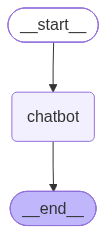

In [51]:
from IPython.display import Image, display

display(
    Image(
        graph.get_graph().draw_mermaid_png()
    )
)